In [1]:
import numpy as np

np.set_printoptions(precision=4, suppress=True)

SEED = 42
np.random.seed(SEED)

batch_size = 16         # 每轮噪声 / 生成样本个数
n_iters = 5000           # 训练轮数（建议少量方便手算）
learning_rate = 0.1   # MLP模型学习率
hidden_dim = 16         # MLP模型隐藏层维度，可以自己调大/调小
tau = 1.0              # kernel 温度：exp(-||x-y||^2 / tau)
drift_scale = 1.0      # 漂移步长系数：x_drift = x + drift_scale * V(x)

EVAL_NOISE_SIZE = 100

PRINT_VECS = True           # 是否打印每个向量的具体数值
DECIMALS = 4                # 打印时保留小数位数

plot_steps = 500

In [2]:
# ======================
# 真实数据分布：固定的双峰高斯样本集
# ======================

def get_data_points(
    n_per_mode=20,
    seed=123,
    mu1=None,
    mu2=None,
    sigma=0.1,
):
    """
    返回一个 (2 * n_per_mode, data_dim) 的 numpy 数组，对应：
      - mode 1: N(mu1, sigma^2 I)
      - mode 2: N(mu2, sigma^2 I)
    """
    if mu1 is None:
        mu1 = np.array([1.0, 0.0], dtype=np.float32)
    else:
        mu1 = np.array(mu1, dtype=np.float32)

    if mu2 is None:
        mu2 = np.array([0.0, 1.0], dtype=np.float32)
    else:
        mu2 = np.array(mu2, dtype=np.float32)

    rng = np.random.RandomState(seed)

    # 两个模态的样本
    eps1 = rng.randn(n_per_mode, 2).astype(np.float32)
    eps2 = rng.randn(n_per_mode, 2).astype(np.float32)

    data1 = mu1[None, :] + sigma * eps1   # (n_per_mode, D)
    data2 = mu2[None, :] + sigma * eps2   # (n_per_mode, D)

    data = np.vstack([data1, data2])      # (2 * n_per_mode, D)
    return data

# 整个 notebook 生命周期内，这批数据是固定的
DATA_POINTS = get_data_points(
    n_per_mode=50,   # 每个模态 50 个点
    seed=123,
    sigma=0.1,        # 模态内的散布程度，越小越“集中在一个点”
)

print("DATA_POINTS shape:", DATA_POINTS.shape)
print("first 5 data points:")
print(DATA_POINTS[:5])

DATA_POINTS shape: (100, 2)
first 5 data points:
[[ 0.8914  0.0997]
 [ 1.0283 -0.1506]
 [ 0.9421  0.1651]
 [ 0.7573 -0.0429]
 [ 1.1266 -0.0867]]


In [3]:
# ======================
# 噪声分布
# ======================

def sample_noise(batch_size):
    """
    从标准高斯 N(0, I) 采样噪声 (batch_size, noise_dim)。
    你可以改成 uniform / mixture 等等。
    """
    return np.random.randn(batch_size, 2).astype(np.float32)

In [4]:
# ======================
# 非线性生成器模型：两层隐藏层 MLP
#   h1 = tanh(W1 * eps + b1)
#   h2 = tanh(W2 * h1 + b2)
#   x  = W3 * h2 + b3
# ======================

def init_nonlinear_generator(noise_dim, data_dim, hidden_dim):
    """
    初始化两层隐藏层 MLP 的参数：
      W1: (hidden_dim, noise_dim)
      b1: (hidden_dim,)
      W2: (hidden_dim, hidden_dim)
      b2: (hidden_dim,)
      W3: (data_dim, hidden_dim)
      b3: (data_dim,)
    用小高斯随机数初始化权重，偏置置零。
    """
    H = hidden_dim
    d = noise_dim
    D = data_dim

    W1 = 0.1 * np.random.randn(H, d).astype(np.float32)
    b1 = np.zeros((H,), dtype=np.float32)

    W2 = 0.1 * np.random.randn(H, H).astype(np.float32)
    b2 = np.zeros((H,), dtype=np.float32)

    W3 = 0.1 * np.random.randn(D, H).astype(np.float32)
    b3 = np.zeros((D,), dtype=np.float32)

    return {"W1": W1, "b1": b1,
            "W2": W2, "b2": b2,
            "W3": W3, "b3": b3}


def generator_forward(params, eps):
    """
    前向传播：
      eps: (batch_size, noise_dim)
      返回 x: (batch_size, data_dim)
    模型：
      z1 = eps @ W1^T + b1
      h1 = tanh(z1)
      z2 = h1  @ W2^T + b2
      h2 = tanh(z2)
      x  = h2  @ W3^T + b3
    """
    W1, b1 = params["W1"], params["b1"]  # W1: (H, d)
    W2, b2 = params["W2"], params["b2"]  # W2: (H, H)
    W3, b3 = params["W3"], params["b3"]  # W3: (D, H)

    # 第一层
    z1 = eps @ W1.T + b1[None, :]   # (N, H)
    h1 = np.tanh(z1)                # (N, H)

    # 第二层
    z2 = h1 @ W2.T + b2[None, :]    # (N, H)
    h2 = np.tanh(z2)                # (N, H)

    # 输出层
    x  = h2 @ W3.T + b3[None, :]    # (N, D)
    return x


def generator_loss_and_grads(params, eps, x_target):
    """
    计算 MSE loss 和对 W1, b1, W2, b2, W3, b3 的梯度。
    loss = mean_i ||f(eps_i) - x_target_i||^2
    """
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]
    W3, b3 = params["W3"], params["b3"]

    batch_size = eps.shape[0]

    # ----- forward -----
    z1 = eps @ W1.T + b1[None, :]   # (N, H)
    h1 = np.tanh(z1)                # (N, H)

    z2 = h1 @ W2.T + b2[None, :]    # (N, H)
    h2 = np.tanh(z2)                # (N, H)

    x_pred = h2 @ W3.T + b3[None, :]  # (N, D)

    diff = x_pred - x_target          # (N, D)
    loss = np.mean(np.sum(diff ** 2, axis=1))

    # ----- backward -----
    # dL/dx_pred
    dL_dx = (2.0 / batch_size) * diff        # (N, D)

    # ---- 输出层 W3, b3 ----
    # x_pred = h2 @ W3^T + b3
    grad_W3 = dL_dx.T @ h2                   # (D, H)
    grad_b3 = np.sum(dL_dx, axis=0)          # (D,)

    # dL/dh2 = dL/dx_pred @ W3
    dL_dh2 = dL_dx @ W3                      # (N, H)

    # ---- 第二隐藏层 ----
    # h2 = tanh(z2)
    dh2_dz2 = 1.0 - np.tanh(z2) ** 2         # (N, H)
    dL_dz2 = dL_dh2 * dh2_dz2                # (N, H)

    # z2 = h1 @ W2^T + b2
    grad_W2 = dL_dz2.T @ h1                  # (H, H)
    grad_b2 = np.sum(dL_dz2, axis=0)         # (H,)

    # dL/dh1 = dL/dz2 @ W2
    dL_dh1 = dL_dz2 @ W2                     # (N, H)

    # ---- 第一隐藏层 ----
    # h1 = tanh(z1)
    dh1_dz1 = 1.0 - np.tanh(z1) ** 2         # (N, H)
    dL_dz1 = dL_dh1 * dh1_dz1                # (N, H)

    # z1 = eps @ W1^T + b1
    grad_W1 = dL_dz1.T @ eps                 # (H, d)
    grad_b1 = np.sum(dL_dz1, axis=0)         # (H,)

    grads = {
        "W1": grad_W1,
        "b1": grad_b1,
        "W2": grad_W2,
        "b2": grad_b2,
        "W3": grad_W3,
        "b3": grad_b3,
    }
    return loss, grads


def generator_step(params, grads, lr):
    """
    简单 SGD 更新所有参数。
    """
    new_params = {
        "W1": params["W1"] - lr * grads["W1"],
        "b1": params["b1"] - lr * grads["b1"],
        "W2": params["W2"] - lr * grads["W2"],
        "b2": params["b2"] - lr * grads["b2"],
        "W3": params["W3"] - lr * grads["W3"],
        "b3": params["b3"] - lr * grads["b3"],
    }
    return new_params

In [5]:
# ======================
# 核函数（可以替换）
# ======================

def rbf_kernel(x, y, tau=1.0):
    """
    x: (..., D)
    y: (..., D)
    返回标量核值 exp(-||x - y||^2 / tau)。
    这里只实现点对点，用的时候会自己 loop。
    """
    diff = x - y
    dist2 = np.sum(diff * diff)
    return float(np.exp(-dist2 / tau))


# ======================
# drifting 场（原文的 mean-shift 版本）
# ======================

def compute_mean_shift(x, points, tau):
    """
    对一个点 x，给定一组点 points（正样本或负样本），
    计算 mean-shift:
        m(x) = sum_j w_j(x) * (points_j - x)
      w_j(x) = k(x, points_j) / sum_l k(x, points_l)
    返回向量 m(x) (D,)
    """
    if points.shape[0] == 0:
        return np.zeros_like(x)

    ks = []
    for j in range(points.shape[0]):
        ks.append(rbf_kernel(x, points[j], tau=tau))
    ks = np.array(ks, dtype=np.float32)
    Z = np.sum(ks)
    if Z == 0.0:
        # 所有核值都极小，退化成平均
        w = np.ones_like(ks) / len(ks)
    else:
        w = ks / Z

    # m(x) = sum_j w_j * (points_j - x)
    diffs = points - x[None, :]           # (N, D)
    m = np.sum(w[:, None] * diffs, axis=0)  # (D,)
    return m


def drifting_field(x_batch, data_points, neg_points, tau):
    """
    对 batch 中每个 x_i，计算 drifting 向量 V(x_i)：
      V(x) = m_pos(x) - m_neg(x)
      m_pos: 对 data_points 的 mean-shift
      m_neg: 对 neg_points 的 mean-shift
    返回 V: (batch_size, D)，以及中间的 m_pos, m_neg（方便打印）
    """
    batch_size = x_batch.shape[0]
    D = x_batch.shape[1]
    V = np.zeros_like(x_batch)
    M_pos = np.zeros_like(x_batch)
    M_neg = np.zeros_like(x_batch)

    for i in range(batch_size):
        x = x_batch[i]
        m_pos = compute_mean_shift(x, data_points, tau=tau)
        m_neg = compute_mean_shift(x, neg_points, tau=tau)
        v = m_pos - m_neg

        V[i] = v
        M_pos[i] = m_pos
        M_neg[i] = m_neg

    return V, M_pos, M_neg

In [6]:
# ======================
# 一些小工具函数：距离、打印等
# ======================

def nearest_data_dist(x, data_points):
    """
    返回 x 到所有 data_points 的最小欧氏距离。
    """
    diffs = data_points - x[None, :]
    dists = np.sqrt(np.sum(diffs ** 2, axis=1))
    return float(np.min(dists))


def format_vec(v, decimals=DECIMALS):
    return np.array2string(np.array(v), precision=decimals, suppress_small=True)


def print_header(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80 + "\n")

In [7]:
import matplotlib.pyplot as plt

def draw(
    x_eval,
    eval_eps,
    data_points,
    plot_title
):
    
    # 每个 eval 样本更接近哪一个 data 样本（或者哪一个 mode）
    diffs = data_points[None, :, :] - x_eval[:, None, :]  # (N_eval, N_data, D)
    dists2 = np.sum(diffs ** 2, axis=2)                   # (N_eval, N_data)
    nearest_idx = np.argmin(dists2, axis=1)               # (N_eval,)
    
    # 粗暴地：看最近的数据点是来自 data1 还是 data2（前一半 vs 后一半）
    mode_assign = (nearest_idx >= data_points.shape[0] // 2).astype(int)  # 0 或 1
    
    count_mode0 = np.sum(mode_assign == 0)
    count_mode1 = np.sum(mode_assign == 1)
    
    print("Eval assignments to modes:")
    print(f"  mode 0 count: {count_mode0}")
    print(f"  mode 1 count: {count_mode1}")
    print(f"  ratio: mode0 {count_mode0/len(mode_assign):.3f}, mode1 {count_mode1/len(mode_assign):.3f}")

    plt.figure(figsize=(5,5))
    colors = ['tab:blue' if a==0 else 'tab:orange' for a in mode_assign]
    plt.scatter(x_eval[:,0], x_eval[:,1], c=colors, alpha=0.4, s=10, label="generated")
    
    # 同时把真实 data 的前两维画出来
    plt.scatter(data_points[:,0], data_points[:,1], c='k', s=15, alpha=0.5, label="data")
    
    plt.xlabel("x[0]")
    plt.ylabel("x[1]")
    plt.xlim([-0.4, 1.4])
    plt.ylim([-0.4, 1.4])
    plt.title(f"Generated vs data (first 2 dims, {plot_title})")
    plt.legend()
    plt.grid(True)
    plt.show()

In [8]:
# 固定一组 eval 噪声，用来评估训练进展（不要每轮都变）
EVAL_NOISE = sample_noise(EVAL_NOISE_SIZE)


def evaluate_metrics(params, eval_eps, data_points, tau, plot_title=None):
    """
    在一组固定的 eval_eps 上评估两个指标：
      1) mean_dist: 平均最近真实点距离
      2) drift_energy: 平均 ||V(x)||^2
    """
    # 生成 eval 样本
    x_eval = generator_forward(params, eval_eps)  # (N_eval, D)

    # 1. 平均最近距离
    dists = [nearest_data_dist(x_eval[i], data_points) for i in range(x_eval.shape[0])]
    mean_dist = float(np.mean(dists))

    # 2. drift energy: E[||V(x)||^2]
    #    负样本集就用 x_eval 本身
    V_eval, _, _ = drifting_field(x_eval, data_points, x_eval, tau=tau)
    V_norm2 = np.sum(V_eval ** 2, axis=1)
    drift_energy = float(np.mean(V_norm2))

    # 3. 可视化
    if plot_title is not None:
        draw(x_eval, eval_eps, data_points, plot_title)

    return mean_dist, drift_energy

In [9]:
# ======================
# 主训练循环（详细文本输出）
# ======================

def run_drifting_toy(
    n_iters=3,
    batch_size=2,
    learning_rate=0.05,
    tau=1.0,
    drift_scale=1.0,
    plot_steps=10
):
    # 初始化模型参数（非线性 MLP）
    params = init_nonlinear_generator(2, 2, hidden_dim)
    data_points = DATA_POINTS

    # 记录指标的历史
    metric_history = {
        "mean_dist_eval": [],
        "drift_energy_eval": [],
    }

    print_header("Initial model parameters (MLP)")
    print("\nData points:")
    print(format_vec(data_points))

    # 先在初始参数上评估一次
    md0, de0 = evaluate_metrics(params, EVAL_NOISE, data_points, tau)
    metric_history["mean_dist_eval"].append(md0)
    metric_history["drift_energy_eval"].append(de0)
    print("\n[Eval @ iter -1] (before training)")
    print(f"  mean_dist_eval    = {md0:.4f}")
    print(f"  drift_energy_eval = {de0:.4f}")

    for it in range(n_iters):
        print_header(f"Iteration {it}")

        # 1. 采样噪声
        eps = sample_noise(batch_size)
        print(f"[1] Sampled noise eps (batch_size={batch_size}):")
        print(format_vec(eps))

        # 2. 生成样本 x = f_theta(eps)
        x = generator_forward(params, eps)
        print("\n[2] Generated samples x = f_theta(eps):")
        for i in range(batch_size):
            print(f"  x[{i}] = {format_vec(x[i])} (from eps[{i}] = {format_vec(eps[i])})")

        # 3. 以当前 batch 为负样本，计算 drifting 场
        neg_points = x.copy()
        V, M_pos, M_neg = drifting_field(x, data_points, neg_points, tau=tau)

        print("\n[3] Drifting field components (for each sample):")
        for i in range(batch_size):
            print(f"  Sample {i}:")
            print(f"    x[{i}]      = {format_vec(x[i])}")
            print(f"    m_pos[{i}]  = {format_vec(M_pos[i])}")
            print(f"    m_neg[{i}]  = {format_vec(M_neg[i])}")
            print(f"    V[{i}]      = m_pos - m_neg = {format_vec(V[i])}")

        # 4. 漂移后的目标位置 x_drift = x + drift_scale * V
        x_drift = x + drift_scale * V
        print("\n[4] Drifted target samples x_drift = x + drift_scale * V:")
        for i in range(batch_size):
            print(f"  x_drift[{i}] = {format_vec(x_drift[i])}")

        # 5. 当前训练 batch 的距离（仅用于直觉，不作为 eval 指标）
        dists_before = [nearest_data_dist(x[i], data_points) for i in range(batch_size)]
        dists_after  = [nearest_data_dist(x_drift[i], data_points) for i in range(batch_size)]
        print("\n[5] Distances to nearest data point (training batch, for intuition):")
        for i in range(batch_size):
            print(f"  sample {i}: before = {dists_before[i]:.4f}, after drift = {dists_after[i]:.4f}")
        print(f"  Mean distance before (train batch): {np.mean(dists_before):.4f}")
        print(f"  Mean distance after  (train batch): {np.mean(dists_after):.4f}")

        # 6. 用 x_drift 作为监督信号，计算 loss 和梯度
        loss, grads = generator_loss_and_grads(params, eps, x_drift)
        print(f"\n[6] Loss (MSE between f_theta(eps) and x_drift): {loss:.6f}")
        print("    Grad shapes:")
        print("      W1:", grads["W1"].shape, " b1:", grads["b1"].shape)
        print("      W2:", grads["W2"].shape, " b2:", grads["b2"].shape)

        # 7. 更新参数
        params = generator_step(params, grads, learning_rate)
        print("\n[7] Updated model parameters")

        # 8. Sanity check：新参数在当前 batch 上对比 x_drift
        x_new = generator_forward(params, eps)
        print("\n[8] Sanity check: f_theta_new(eps) vs x_drift (train batch):")
        for i in range(batch_size):
            print(f"  new x[{i}]       = {format_vec(x_new[i])}")
            print(f"  tgt x_drift[{i}] = {format_vec(x_drift[i])}")
            diff_norm = np.linalg.norm(x_new[i] - x_drift[i])
            print(f"    ||new - tgt|| = {diff_norm:.6f}")

        # 9. 在固定 eval 噪声上评估指标
        if it % plot_steps == 0 or it == n_iters - 1:
            md, de = evaluate_metrics(params, EVAL_NOISE, data_points, tau, f"Iter {it}")
        else:
            md, de = evaluate_metrics(params, EVAL_NOISE, data_points, tau, None)
        metric_history["mean_dist_eval"].append(md)
        metric_history["drift_energy_eval"].append(de)

        print("\n[9] Eval metrics on fixed EVAL_NOISE:")
        print(f"  mean_dist_eval    = {md:.4f}")
        print(f"  drift_energy_eval = {de:.4f}")

        print("\n" + "-" * 80)

    print_header("Training finished")

    return params, metric_history

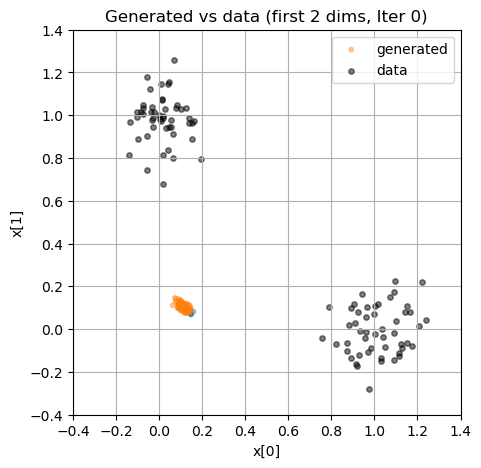

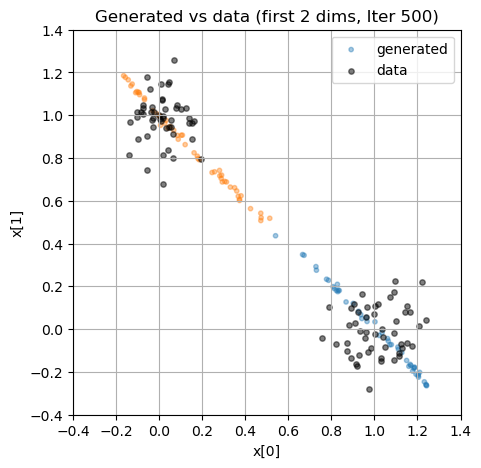

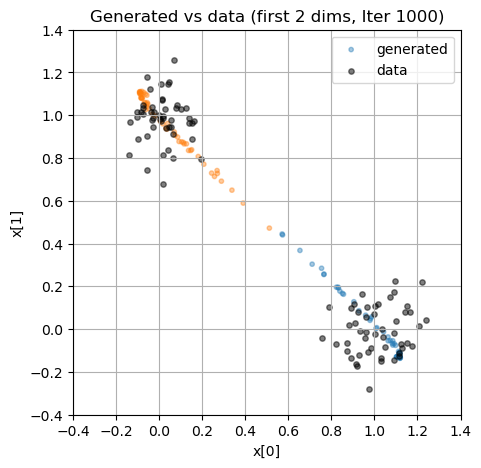

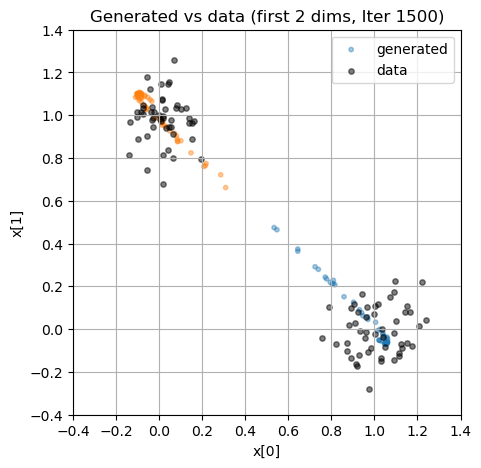

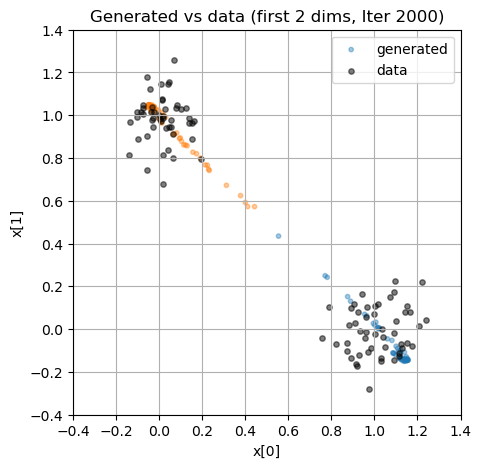

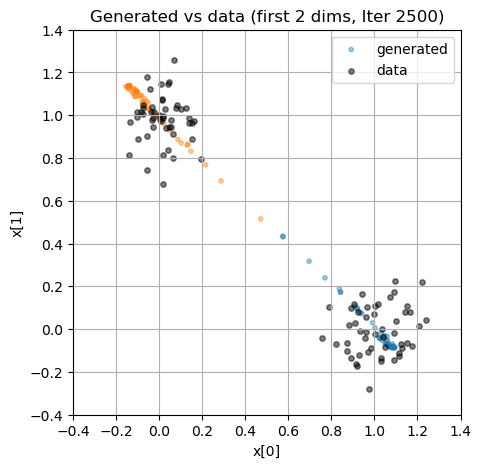

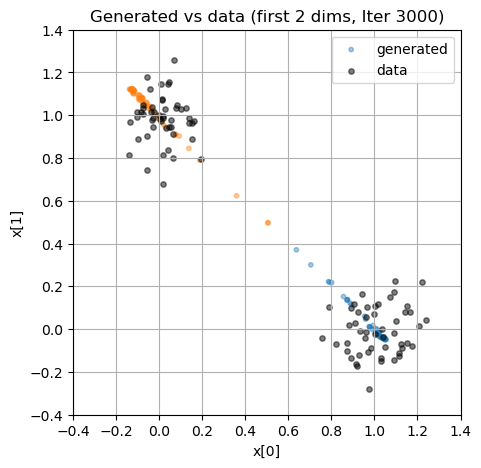

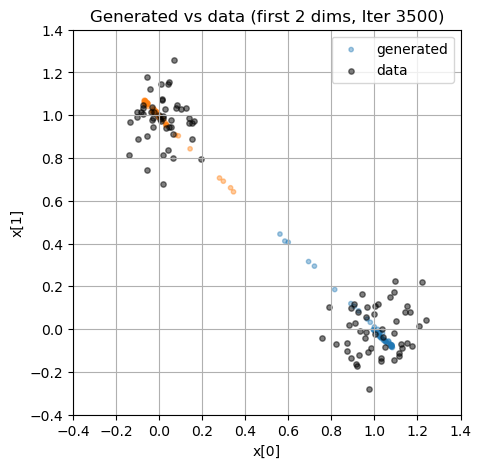

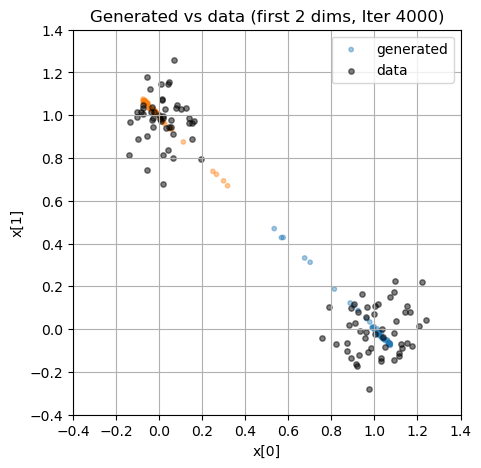

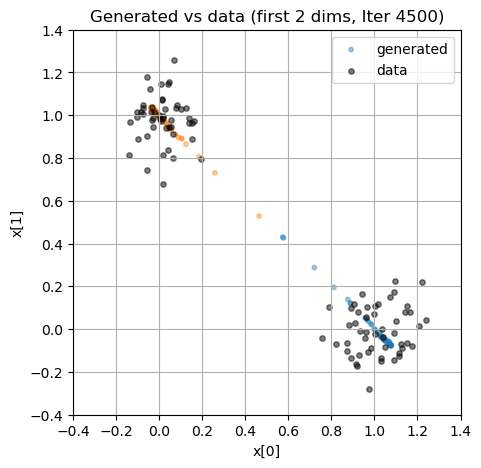

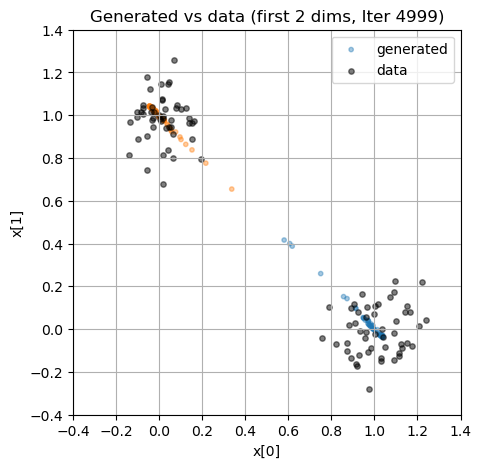

Done in 305.97s


In [10]:
import time
import contextlib
import matplotlib.pyplot as plt

# 跑一遍训练
log_path = "drifting_log.txt"  # 会保存在和 notebook 同目录
start_time = time.perf_counter()
with open(log_path, "w", encoding="utf-8") as f, contextlib.redirect_stdout(f):
    final_params, metric_history = run_drifting_toy(
        n_iters=n_iters,
        batch_size=batch_size,
        learning_rate=learning_rate,
        tau=tau,
        drift_scale=drift_scale,
        plot_steps=plot_steps
    )
end_time = time.perf_counter()
duration = round(end_time - start_time, 2)

print(f"Done in {duration}s")

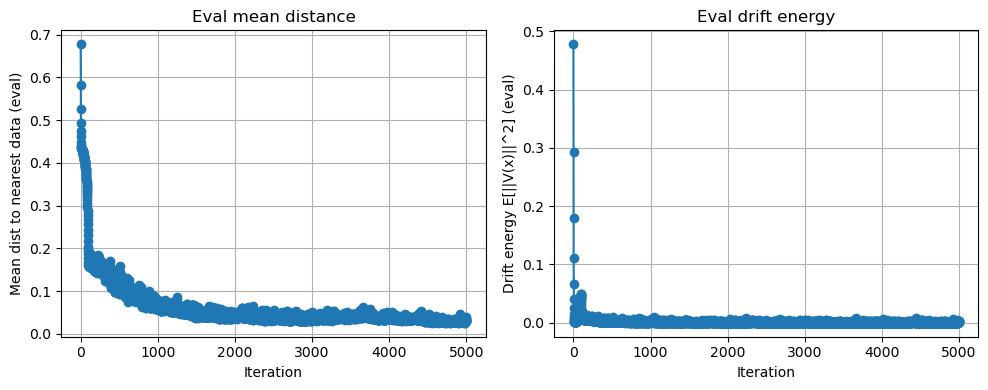

In [11]:
# 可视化 eval 指标
iters = np.arange(len(metric_history["mean_dist_eval"]))  # 包含 iter=-1 的初始点

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(iters, metric_history["mean_dist_eval"], marker="o")
plt.xlabel("Iteration")
plt.ylabel("Mean dist to nearest data (eval)")
plt.title("Eval mean distance")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(iters, metric_history["drift_energy_eval"], marker="o")
plt.xlabel("Iteration")
plt.ylabel("Drift energy E[||V(x)||^2] (eval)")
plt.title("Eval drift energy")
plt.grid(True)

plt.tight_layout()
plt.show()